# Cuaderno 07 - Clasificación con KNN (K-Nearest Neighbors)

En este cuaderno vamos a estudiar un nuevo modelo de clasificación supervisada: **K-Nearest Neighbors**, también conocido como **KNN** o **K vecinos más cercanos**.

A diferencia de otros modelos que intentan ajustar una fórmula o aprender una relación matemática explícita entre las variables, KNN toma sus decisiones de una manera más directa: observa cuáles son los casos más cercanos al registro que queremos clasificar y asigna la clase más frecuente entre esos vecinos.

La idea central del modelo puede resumirse así:

> Para clasificar un nuevo caso, KNN mira a su alrededor y decide según los ejemplos más parecidos que ya conoce.

Durante el recorrido de este cuaderno vamos a trabajar con un dataset tabular, entrenar modelos KNN con distintos valores de `k`, evaluar sus resultados y analizar por qué el escalado de los datos es un paso fundamental antes de aplicar este algoritmo.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- Comprender la lógica general del algoritmo **K-Nearest Neighbors**.
- Explicar por qué la **distancia** entre datos es clave para el funcionamiento de KNN.
- Entender cómo influye el valor de `k` en las predicciones del modelo.
- Aplicar escalado de variables antes de entrenar un modelo basado en distancias.
- Entrenar y evaluar un modelo KNN usando `scikit-learn`.
- Comparar el rendimiento de distintos valores de `k`.
- Interpretar métricas de clasificación como `accuracy`, `precision`, `recall`, `f1-score` y matriz de confusión.

## Nota sobre el dataset utilizado

> En este cuaderno trabajaremos con un dataset médico relacionado con diagnósticos de tumores mamarios. Los datos están anonimizados y se utilizarán únicamente con fines educativos para estudiar un modelo de clasificación.

> El objetivo no es realizar diagnósticos médicos reales, sino comprender cómo funciona el algoritmo **K-Nearest Neighbors** sobre datos numéricos.

> A lo largo del cuaderno hablaremos de clasificar registros del dataset como **benignos** o **malignos**, pero siempre dentro de un contexto educativo y técnico. Este modelo no debe interpretarse como una herramienta médica real.

## ¿Qué es K-Nearest Neighbors?

**K-Nearest Neighbors**, o **KNN**, es un algoritmo de aprendizaje supervisado que puede utilizarse para resolver problemas de clasificación.

Su idea principal es muy intuitiva: para clasificar un nuevo registro, el modelo busca cuáles son los registros más parecidos que ya conoce y observa a qué clase pertenecen.

Por ejemplo, si queremos clasificar un nuevo caso y elegimos `k = 5`, el modelo buscará los **5 vecinos más cercanos** dentro del conjunto de entrenamiento. Luego revisará sus clases y asignará la clase que aparezca con mayor frecuencia.

Si entre esos 5 vecinos hay:

- 3 registros de la clase A,
- 2 registros de la clase B,

entonces KNN clasificará el nuevo caso como **clase A**.

A diferencia de otros modelos, KNN no construye una fórmula interna ni aprende coeficientes durante una etapa de entrenamiento tradicional. En cambio, conserva los datos de entrenamiento y toma decisiones al momento de clasificar nuevos registros.

Por eso, podemos pensar a KNN como un modelo que clasifica **mirando alrededor**.

## La distancia como idea central del modelo

Para que KNN pueda decidir cuáles son los vecinos más cercanos, necesita medir la **distancia** entre los registros.

Si cada registro tiene dos variables, podemos imaginarlo como un punto en un plano. Por ejemplo:

- eje horizontal: una primera variable numérica,
- eje vertical: una segunda variable numérica.

Cuando llega un nuevo registro, KNN calcula qué tan lejos está de los registros ya conocidos. Luego selecciona los `k` registros más cercanos y usa sus clases para tomar una decisión.

La distancia más utilizada en KNN es la **distancia euclidiana**, que mide la separación “en línea recta” entre dos puntos.

En dos dimensiones, si tenemos dos puntos:

- Punto 1: `(x1, y1)`
- Punto 2: `(x2, y2)`

la distancia entre ellos se calcula como:

$$
distancia = \sqrt{(x2 - x1)^2 + (y2 - y1)^2}
$$

Esta fórmula nos dice algo importante: si una variable tiene valores mucho más grandes que otra, puede dominar el cálculo de la distancia.

Por eso, antes de aplicar KNN, será fundamental **escalar las variables numéricas**.

## ¿Qué vamos a hacer en este cuaderno?

A lo largo de este cuaderno vamos a seguir un recorrido completo de trabajo con un modelo de clasificación basado en **K-Nearest Neighbors**.

Vamos a trabajar paso a paso:

1. Cargar el dataset.
2. Explorar sus columnas y comprender qué representa cada variable.
3. Identificar la variable objetivo.
4. Preparar los datos para que puedan ser usados por el modelo.
5. Separar los datos en entrenamiento y prueba.
6. Entrenar un primer modelo KNN.
7. Analizar por qué el escalado de variables es fundamental en este algoritmo.
8. Entrenar modelos KNN con distintos valores de `k`.
9. Evaluar los resultados usando métricas de clasificación.
10. Interpretar la matriz de confusión.
11. Comparar los resultados con un modelo de regresión logística.
12. Reflexionar sobre las ventajas y limitaciones de KNN.

La idea no es solamente ejecutar código, sino entender cómo piensa este tipo de modelo.

En particular, vamos a prestar atención a tres preguntas centrales:

- ¿Cómo decide KNN a qué clase pertenece un nuevo registro?
- ¿Por qué la distancia entre datos es tan importante?
- ¿Qué cambia cuando modificamos el valor de `k`?

## Importación de librerias y carga del dataset

In [1]:
# ---------------------------------------------------------
# Importación de librerías y carga del dataset
# ---------------------------------------------------------
# !pip install -q kagglehub

# Librerías generales
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Librerías de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Librería para descargar datasets desde Kaggle
import kagglehub

# ---------------------------------------------------------
# Descarga del dataset
# ---------------------------------------------------------

# Descargamos el dataset Breast Cancer Wisconsin desde Kaggle
ruta_dataset = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

# Mostramos los archivos disponibles dentro de la carpeta descargada
print("Ruta del dataset:", ruta_dataset)
print("Archivos encontrados:", os.listdir(ruta_dataset))

# Cargamos el archivo CSV principal
archivo_csv = os.path.join(ruta_dataset, "data.csv")
df = pd.read_csv(archivo_csv)

# Mostramos las primeras filas del dataset
df.head()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Ruta del dataset: /kaggle/input/breast-cancer-wisconsin-data
Archivos encontrados: ['data.csv']


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Primer vistazo al dataset

Ya tenemos cargado el dataset en un DataFrame llamado `df`.

Al observar las primeras filas vemos que cada registro representa un caso del dataset y que la columna más importante para nuestro problema es `diagnosis`.

Esa columna contiene la clase que queremos predecir:

- `M`: registro clasificado como maligno.
- `B`: registro clasificado como benigno.

Además, el dataset incluye muchas columnas numéricas, como `radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`, entre otras. Estas variables describen distintas características medidas sobre cada registro.

También podemos observar dos columnas que probablemente no serán útiles para entrenar el modelo:

- `id`: es un identificador del registro, no una variable predictora.
- `Unnamed: 32`: aparece vacía, con valores `NaN`.

Más adelante vamos a eliminar esas columnas antes de entrenar el modelo.

## Exploración inicial del dataset

In [2]:
# ---------------------------------------------------------
# Exploración inicial del dataset
# ---------------------------------------------------------

# Cantidad de filas y columnas
print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas del dataset:")
print(df.columns)

print("\nInformación general:")
df.info()

print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset:
(569, 33)

Columnas del dataset:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null

## Interpretación de la exploración inicial

El dataset tiene **569 registros** y **33 columnas**.

La mayoría de las columnas son numéricas (`float64`), lo cual es muy conveniente para trabajar con KNN, porque este algoritmo calcula distancias entre registros. Cuanto más directamente numéricas sean las variables, más sencillo será preparar los datos para el modelo.

También observamos algunos puntos importantes:

- La columna `diagnosis` es la variable objetivo. Es la clase que queremos predecir.
- La columna `id` identifica cada registro, pero no aporta información útil para clasificar.
- La columna `Unnamed: 32` está completamente vacía: tiene 569 valores nulos.
- El resto de las variables no tiene valores faltantes.

Por lo tanto, antes de entrenar el modelo vamos a eliminar las columnas `id` y `Unnamed: 32`.

También vamos a transformar la variable `diagnosis`, que actualmente contiene texto (`M` y `B`), en valores numéricos para poder usarla con los modelos de Machine Learning.

## Limpieza básica del dataset

La celda siguiente nos deja un dataset más adecuado para modelar: sin identificadores, sin columnas vacías y con la variable objetivo codificada numéricamente.

In [4]:
# ---------------------------------------------------------
# Limpieza básica del dataset
# ---------------------------------------------------------

# Creamos una copia del DataFrame original para trabajar con seguridad
df_limpio = df.copy()

# Eliminamos columnas que no aportan al modelo
df_limpio = df_limpio.drop(columns=["id", "Unnamed: 32"])

# Transformamos la variable objetivo:
# M = 1
# B = 0
df_limpio["diagnosis"] = df_limpio["diagnosis"].map({
    "M": 1,
    "B": 0
})

# Verificamos el resultado
print("Dimensiones luego de la limpieza:")
print(df_limpio.shape)

print("\nPrimeras filas del dataset limpio:")
display(df_limpio.head())

print("\nValores de la variable objetivo:")
print(df_limpio["diagnosis"].value_counts())

Dimensiones luego de la limpieza:
(569, 31)

Primeras filas del dataset limpio:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Valores de la variable objetivo:
diagnosis
0    357
1    212
Name: count, dtype: int64


## Dataset limpio y variable objetivo

Después de la limpieza, el dataset quedó con **569 registros** y **31 columnas**.

Eliminamos dos columnas:

- `id`, porque era solo un identificador de cada registro.
- `Unnamed: 32`, porque estaba completamente vacía.

También transformamos la columna `diagnosis` para poder usarla en modelos de Machine Learning:

- `0`: registro clasificado como benigno.
- `1`: registro clasificado como maligno.

Esta transformación es necesaria porque los modelos trabajan mejor con valores numéricos que con etiquetas de texto.

Al revisar la cantidad de registros por clase, vemos que hay:

- 357 registros de la clase `0`.
- 212 registros de la clase `1`.

Esto nos muestra que las clases no están perfectamente balanceadas, pero tampoco tenemos un desbalance extremo. De todos modos, será importante mirar métricas como `precision`, `recall` y `f1-score`, y no quedarnos solamente con el `accuracy`.

## Distribución de la variable objetivo

Esta celda muestra visualmente si las clases están equilibradas o no, algo importante antes de evaluar cualquier modelo de clasificación.

Distribución de la variable objetivo:
diagnosis
0    357
1    212
Name: count, dtype: int64


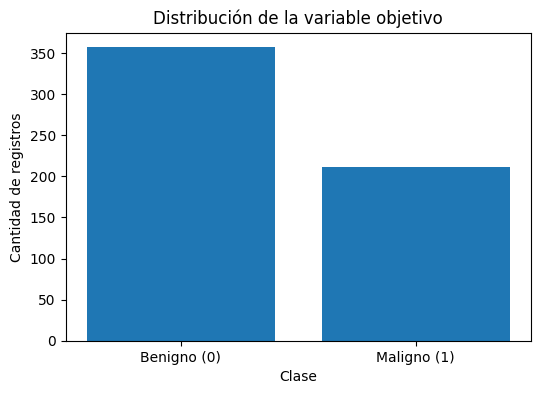

In [5]:
# ---------------------------------------------------------
# Distribución de la variable objetivo
# ---------------------------------------------------------

# Contamos cuántos registros hay de cada clase
conteo_clases = df_limpio["diagnosis"].value_counts().sort_index()

print("Distribución de la variable objetivo:")
print(conteo_clases)

# Graficamos la distribución
plt.figure(figsize=(6, 4))
plt.bar(["Benigno (0)", "Maligno (1)"], conteo_clases.values)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad de registros")
plt.show()

## Separación entre variables predictoras y variable objetivo

Para entrenar un modelo de Machine Learning necesitamos separar el dataset en dos partes:

- `X`: contiene las variables predictoras, es decir, las columnas que el modelo usará para tomar decisiones.
- `y`: contiene la variable objetivo, es decir, la clase que queremos predecir.

En este caso, la variable objetivo es `diagnosis`.

Todas las demás columnas numéricas serán utilizadas como variables predictoras.

## Separación de variables predictoras y objetivo

In [6]:
# ---------------------------------------------------------
# Separación de variables predictoras y objetivo
# ---------------------------------------------------------

# Variable objetivo
y = df_limpio["diagnosis"]

# Variables predictoras
X = df_limpio.drop(columns=["diagnosis"])

# Verificamos las dimensiones
print("Dimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

print("\nPrimeras filas de X:")
display(X.head())

print("\nPrimeros valores de y:")
display(y.head())

Dimensiones de X:
(569, 30)

Dimensiones de y:
(569,)

Primeras filas de X:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Primeros valores de y:


,diagnosis
0,1
1,1
2,1
3,1
4,1


## División entre entrenamiento y prueba

Antes de entrenar el modelo, vamos a dividir los datos en dos conjuntos:

- **Conjunto de entrenamiento**: se utiliza para que el modelo aprenda a clasificar.
- **Conjunto de prueba**: se utiliza para evaluar cómo funciona el modelo con datos que no vio antes.

Esta separación es fundamental porque no queremos medir el rendimiento del modelo usando los mismos datos con los que fue entrenado.

En este caso usaremos el 80% de los datos para entrenamiento y el 20% para prueba.

También usaremos el parámetro `stratify=y`. Esto permite que la proporción entre registros benignos y malignos se mantenga de forma similar tanto en el conjunto de entrenamiento como en el conjunto de prueba.

In [7]:
# ---------------------------------------------------------
# División entre entrenamiento y prueba
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verificamos las dimensiones de cada conjunto
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

print("\nDistribución de clases en y_train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribución de clases en y_test:")
print(y_test.value_counts(normalize=True).sort_index())

Dimensiones de X_train: (455, 30)
Dimensiones de X_test: (114, 30)
Dimensiones de y_train: (455,)
Dimensiones de y_test: (114,)

Distribución de clases en y_train:
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Distribución de clases en y_test:
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


## Primer modelo KNN sin escalar los datos

Vamos a entrenar un primer modelo KNN usando los datos tal como están.

Esto nos servirá como punto de comparación, pero debemos tener en cuenta algo importante: **KNN calcula distancias entre registros**. Si las variables tienen escalas muy distintas, algunas columnas pueden influir mucho más que otras solamente porque sus valores son más grandes.

Por ejemplo, una variable como `area_mean` puede tener valores mucho más altos que una variable como `smoothness_mean`. Si no escalamos los datos, las variables de mayor magnitud pueden dominar el cálculo de distancia.

Aun así, vamos a entrenar este primer modelo sin escalado para observar qué ocurre.

In [8]:
# ---------------------------------------------------------
# Primer modelo KNN sin escalado
# ---------------------------------------------------------

# Creamos un modelo KNN con k = 5
knn_sin_escalar = KNeighborsClassifier(n_neighbors=5)

# Entrenamos el modelo con los datos originales
knn_sin_escalar.fit(X_train, y_train)

# Realizamos predicciones sobre el conjunto de prueba
y_pred_sin_escalar = knn_sin_escalar.predict(X_test)

# Calculamos el accuracy
accuracy_sin_escalar = accuracy_score(y_test, y_pred_sin_escalar)

print("Accuracy del modelo KNN sin escalado:")
print(accuracy_sin_escalar)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_sin_escalar, target_names=["Benigno (0)", "Maligno (1)"]))

Accuracy del modelo KNN sin escalado:
0.9122807017543859

Reporte de clasificación:
              precision    recall  f1-score   support

 Benigno (0)       0.89      0.99      0.93        72
 Maligno (1)       0.97      0.79      0.87        42

    accuracy                           0.91       114
   macro avg       0.93      0.89      0.90       114
weighted avg       0.92      0.91      0.91       114



## Interpretación del primer modelo sin escalado

El modelo KNN sin escalado obtuvo un `accuracy` aproximado de **0.91**.

A primera vista, podría parecer un resultado muy bueno. Sin embargo, no conviene analizar solamente el `accuracy`.

Si miramos el reporte de clasificación, vemos que el modelo funciona mejor para la clase `Benigno (0)` que para la clase `Maligno (1)`:

- Para `Benigno (0)`, el `recall` es muy alto.
- Para `Maligno (1)`, el `recall` es más bajo.

Esto significa que el modelo está dejando sin identificar algunos registros de la clase `1`.

Además, debemos recordar que este modelo fue entrenado con variables sin escalar. En KNN, esto es especialmente importante porque el algoritmo calcula distancias entre registros. Si algunas variables tienen valores mucho más grandes que otras, pueden influir demasiado en la clasificación.

Por eso, el próximo paso será escalar las variables y volver a entrenar el modelo.

In [9]:
# ---------------------------------------------------------
# Comparación de escalas entre variables
# ---------------------------------------------------------

# Seleccionamos algunas variables para comparar sus escalas
columnas_comparar = [
    "area_mean",
    "perimeter_mean",
    "smoothness_mean",
    "concavity_mean",
    "fractal_dimension_mean"
]

# Calculamos mínimo, máximo, media y desvío estándar
resumen_escalas = X_train[columnas_comparar].agg(["min", "max", "mean", "std"]).T

# Mostramos el resumen
display(resumen_escalas)

,min,max,mean,std
area_mean,143.50000,2501.00000,659.578242,360.418686
perimeter_mean,43.79000,188.50000,92.215868,24.717118
smoothness_mean,0.06251,0.16340,0.095993,0.014310
concavity_mean,0.00000,0.42680,0.089184,0.081698
fractal_dimension_mean,0.05024,0.09744,0.062715,0.006971


## ¿Por qué necesitamos escalar?

La tabla anterior muestra que las variables no están medidas en la misma escala.

Por ejemplo:

- `area_mean` tiene valores muy grandes, desde aproximadamente 143 hasta 2501.
- `smoothness_mean` tiene valores muy pequeños, entre 0.06 y 0.16.
- `fractal_dimension_mean` también se mueve en un rango muy reducido.

Para otros modelos, esta diferencia de escala puede no ser tan grave. Pero para KNN sí lo es, porque KNN decide calculando distancias.

Si una variable tiene valores mucho más grandes que otra, puede dominar el cálculo de distancia. En ese caso, el modelo podría considerar que dos registros están cerca o lejos principalmente por esa variable, aunque otras características también sean relevantes.

Por eso, antes de aplicar KNN, vamos a estandarizar las variables usando `StandardScaler`.

Este proceso transforma cada variable para que tenga aproximadamente:

- media 0,
- desviación estándar 1.

De esta manera, todas las variables quedan en una escala comparable.

In [10]:
# ---------------------------------------------------------
# Escalado de variables con StandardScaler
# ---------------------------------------------------------

# Creamos el escalador
scaler = StandardScaler()

# Ajustamos el escalador solamente con los datos de entrenamiento
X_train_escalado = scaler.fit_transform(X_train)

# Transformamos el conjunto de prueba usando el mismo escalador
X_test_escalado = scaler.transform(X_test)

# Convertimos los arrays escalados nuevamente a DataFrame
# para conservar los nombres de las columnas
X_train_escalado = pd.DataFrame(
    X_train_escalado,
    columns=X_train.columns,
    index=X_train.index
)

X_test_escalado = pd.DataFrame(
    X_test_escalado,
    columns=X_test.columns,
    index=X_test.index
)

# Mostramos las primeras filas del conjunto escalado
display(X_train_escalado.head())

# Verificamos media y desvío estándar de algunas columnas escaladas
resumen_escalado = X_train_escalado[columnas_comparar].agg(["mean", "std"]).T
display(resumen_escalado)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,...,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
170,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,...,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
407,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,...,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
430,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,...,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
27,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,...,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249


,mean,std
area_mean,-1.171224e-16,1.001101
perimeter_mean,4.704418e-16,1.001101
smoothness_mean,7.242070e-16,1.001101
concavity_mean,-4.489693e-17,1.001101
fractal_dimension_mean,3.669836e-16,1.001101


## Interpretación del escalado

Después de aplicar `StandardScaler`, las variables quedaron en una escala comparable.

Antes del escalado, algunas columnas tenían valores muy grandes y otras valores muy pequeños. Por ejemplo, `area_mean` podía tener valores de cientos o miles, mientras que `smoothness_mean` tenía valores cercanos a cero.

Después del escalado, todas las variables quedan expresadas en función de su distancia respecto de la media.

Esto significa que:

- un valor cercano a `0` está cerca del promedio de esa variable,
- un valor positivo está por encima del promedio,
- un valor negativo está por debajo del promedio.

Este paso es especialmente importante en KNN, porque el modelo calcula distancias. Al escalar las variables, evitamos que una columna influya demasiado solo por tener números más grandes.

También es importante notar que el escalador se ajustó solamente con `X_train` usando `fit_transform()`. Luego se aplicó sobre `X_test` usando `transform()`.

Esto evita que información del conjunto de prueba se filtre durante el entrenamiento.

In [11]:
# ---------------------------------------------------------
# Modelo KNN con datos escalados
# ---------------------------------------------------------

# Creamos un modelo KNN con k = 5
knn_escalado = KNeighborsClassifier(n_neighbors=5)

# Entrenamos el modelo con los datos escalados
knn_escalado.fit(X_train_escalado, y_train)

# Realizamos predicciones sobre el conjunto de prueba escalado
y_pred_escalado = knn_escalado.predict(X_test_escalado)

# Calculamos el accuracy
accuracy_escalado = accuracy_score(y_test, y_pred_escalado)

print("Accuracy del modelo KNN con escalado:")
print(accuracy_escalado)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_escalado, target_names=["Benigno (0)", "Maligno (1)"]))

Accuracy del modelo KNN con escalado:
0.956140350877193

Reporte de clasificación:
              precision    recall  f1-score   support

 Benigno (0)       0.95      0.99      0.97        72
 Maligno (1)       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Comparación entre KNN sin escalado y con escalado

Al comparar los dos modelos, vemos una mejora clara al utilizar los datos escalados.

El modelo KNN sin escalado obtuvo un `accuracy` aproximado de **0.91**.

El modelo KNN con escalado obtuvo un `accuracy` aproximado de **0.96**.

La mejora no aparece solamente en el `accuracy`. También se observa en las métricas de la clase `Maligno (1)`:

- Sin escalado, el `recall` de la clase `1` fue **0.79**.
- Con escalado, el `recall` de la clase `1` subió a **0.90**.

Esto significa que, al escalar las variables, el modelo logró identificar mejor los registros de esa clase.

Este resultado tiene sentido: KNN se basa en distancias. Si las variables no están en escalas comparables, algunas columnas pueden dominar el cálculo de cercanía. En cambio, al escalar los datos, cada variable participa de manera más equilibrada en la distancia total.

A partir de este punto, seguiremos trabajando con los datos escalados.

## Probando distintos valores de k

En KNN, el valor de `k` indica cuántos vecinos cercanos se van a tener en cuenta para clasificar un nuevo registro.

Este valor influye mucho en el comportamiento del modelo:

- Si `k` es muy bajo, el modelo puede volverse demasiado sensible a casos particulares o al ruido.
- Si `k` es muy alto, el modelo puede volverse demasiado general y perder detalles importantes de la distribución de los datos.

Por eso, no existe un único valor de `k` que funcione siempre bien. Es necesario probar distintos valores y comparar los resultados.

En esta sección vamos a entrenar varios modelos KNN usando distintos valores de `k` y vamos a comparar sus métricas.

In [13]:
# ---------------------------------------------------------
# Celda 16 - Evaluación de distintos valores de k
# ---------------------------------------------------------

# Lista de valores de k que vamos a probar
valores_k = [1, 3, 5, 7, 9, 11, 15, 21]

# Lista donde guardaremos los resultados
resultados_k = []

# Probamos cada valor de k
for k in valores_k:
    # Creamos el modelo
    modelo_knn = KNeighborsClassifier(n_neighbors=k)

    # Entrenamos con los datos escalados
    modelo_knn.fit(X_train_escalado, y_train)

    # Predecimos sobre el conjunto de prueba
    y_pred = modelo_knn.predict(X_test_escalado)

    # Obtenemos el reporte como diccionario
    reporte = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    # Guardamos las métricas principales
    resultados_k.append({
        "k": k,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_clase_1": reporte["1"]["precision"],
        "recall_clase_1": reporte["1"]["recall"],
        "f1_clase_1": reporte["1"]["f1-score"]
    })

# Convertimos los resultados a DataFrame
df_resultados_k = pd.DataFrame(resultados_k)

# Mostramos la tabla
display(df_resultados_k)

,k,accuracy,precision_clase_1,recall_clase_1,f1_clase_1
0,1,0.929825,0.925000,0.880952,0.902439
1,3,0.938596,0.972973,0.857143,0.911392
2,5,0.956140,0.974359,0.904762,0.938272
3,7,0.956140,0.974359,0.904762,0.938272
4,9,0.947368,0.973684,0.880952,0.925000
5,11,0.947368,0.973684,0.880952,0.925000
6,15,0.947368,0.973684,0.880952,0.925000
7,21,0.938596,0.972973,0.857143,0.911392


## Interpretación de los distintos valores de k

Al probar diferentes valores de `k`, vemos que el rendimiento del modelo cambia.

En este caso, los mejores resultados aparecen con `k = 5` y `k = 7`.

Ambos valores obtienen:

- `accuracy` aproximado de **0.956**,
- `recall` para la clase `1` de aproximadamente **0.905**,
- `f1-score` para la clase `1` de aproximadamente **0.938**.

También podemos observar que:

- Con `k = 1`, el modelo es más sensible a casos individuales. Su rendimiento es bueno, pero menor que con `k = 5` o `k = 7`.
- Con valores más altos, como `k = 21`, el rendimiento vuelve a bajar.
- Esto muestra que aumentar `k` no siempre mejora el modelo.

La elección de `k` busca un equilibrio: queremos un modelo que no sea demasiado sensible al ruido, pero que tampoco sea tan general que pierda patrones locales importantes.

Para continuar, vamos a utilizar `k = 5`, ya que fue uno de los valores con mejor desempeño y además es un valor habitual para comenzar a trabajar con KNN.

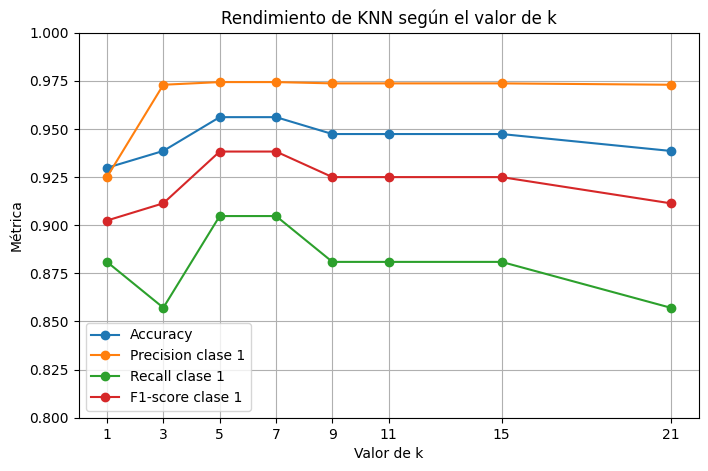

In [14]:
# ---------------------------------------------------------
# Visualización del rendimiento según k
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(df_resultados_k["k"], df_resultados_k["accuracy"], marker="o", label="Accuracy")
plt.plot(df_resultados_k["k"], df_resultados_k["precision_clase_1"], marker="o", label="Precision clase 1")
plt.plot(df_resultados_k["k"], df_resultados_k["recall_clase_1"], marker="o", label="Recall clase 1")
plt.plot(df_resultados_k["k"], df_resultados_k["f1_clase_1"], marker="o", label="F1-score clase 1")

plt.title("Rendimiento de KNN según el valor de k")
plt.xlabel("Valor de k")
plt.ylabel("Métrica")
plt.xticks(df_resultados_k["k"])
plt.ylim(0.80, 1.00)
plt.grid(True)
plt.legend()
plt.show()

## Lectura del gráfico

El gráfico muestra cómo cambian las métricas del modelo cuando modificamos el valor de `k`.

Podemos observar que el rendimiento no mejora de forma constante al aumentar `k`. En este caso, los mejores valores aparecen alrededor de `k = 5` y `k = 7`.

La línea de `precision` de la clase `1` se mantiene alta, lo que indica que cuando el modelo predice esa clase, suele hacerlo correctamente.

Sin embargo, la línea de `recall` cambia más. Esto significa que algunos valores de `k` permiten detectar mejor los registros de la clase `1` que otros.

Este análisis nos muestra que elegir `k` no es un detalle menor. Un valor demasiado bajo puede volver al modelo sensible a casos particulares, mientras que un valor demasiado alto puede hacerlo perder información local.

Matriz de confusión:
[[71  1]
 [ 4 38]]


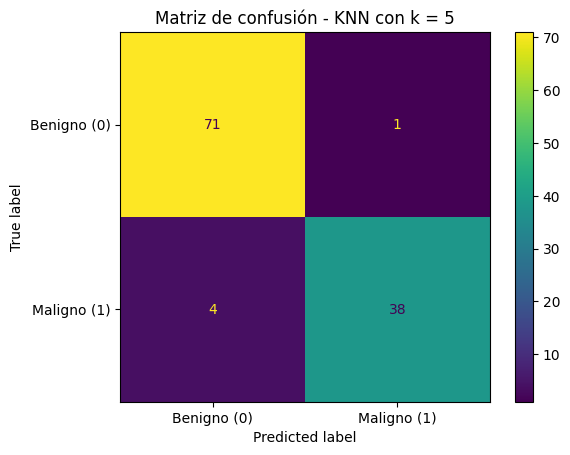

In [15]:
# ---------------------------------------------------------
# Matriz de confusión del modelo KNN elegido
# ---------------------------------------------------------

# Entrenamos nuevamente el modelo elegido
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_escalado, y_train)

# Realizamos predicciones
y_pred_knn_final = knn_final.predict(X_test_escalado)

# Calculamos la matriz de confusión
matriz_knn = confusion_matrix(y_test, y_pred_knn_final)

# Mostramos la matriz como tabla
print("Matriz de confusión:")
print(matriz_knn)

# Mostramos la matriz como gráfico
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_knn,
    display_labels=["Benigno (0)", "Maligno (1)"]
)

disp.plot()
plt.title("Matriz de confusión - KNN con k = 5")
plt.show()

## Interpretación de la matriz de confusión

La matriz de confusión nos permite ver con más detalle qué aciertos y errores cometió el modelo.

En este caso, usando KNN con `k = 5`, obtuvimos:

- **71 verdaderos negativos (VN)**: registros benignos correctamente clasificados como benignos.
- **1 falso positivo (FP)**: registro benigno clasificado incorrectamente como maligno.
- **4 falsos negativos (FN)**: registros malignos clasificados incorrectamente como benignos.
- **38 verdaderos positivos (VP)**: registros malignos correctamente clasificados como malignos.

Esto significa que el modelo clasificó correctamente la mayoría de los registros del conjunto de prueba.

Sin embargo, también cometió algunos errores. En particular, aparecen **4 falsos negativos**, es decir, registros de la clase `1` que el modelo clasificó como clase `0`.

> **IMPORTANTE**: En este cuaderno analizamos estos resultados con fines educativos. En problemas reales de salud, este tipo de error sería especialmente importante y requeriría una evaluación mucho más cuidadosa, con intervención de especialistas y criterios médicos adecuados.

Desde el punto de vista del aprendizaje automático, esta matriz nos permite entender mejor el comportamiento del modelo: no solo cuántas veces acertó, sino también en qué tipo de casos se equivocó.

## Métricas finales del modelo KNN elegido

In [16]:
# ---------------------------------------------------------
# Métricas finales del modelo KNN elegido
# ---------------------------------------------------------

# Generamos el reporte de clasificación como diccionario
reporte_knn_final = classification_report(
    y_test,
    y_pred_knn_final,
    target_names=["Benigno (0)", "Maligno (1)"],
    output_dict=True
)

# Convertimos el reporte a DataFrame para visualizarlo mejor
df_reporte_knn_final = pd.DataFrame(reporte_knn_final).T

# Mostramos la tabla
display(df_reporte_knn_final)

,precision,recall,f1-score,support
Benigno (0),0.946667,0.986111,0.965986,72.00000
Maligno (1),0.974359,0.904762,0.938272,42.00000
accuracy,0.956140,0.956140,0.956140,0.95614
macro avg,0.960513,0.945437,0.952129,114.00000
weighted avg,0.956869,0.956140,0.955776,114.00000


## Métricas finales del modelo KNN

La tabla anterior resume las principales métricas del modelo KNN elegido, usando `k = 5`.

Las métricas más importantes son:

- `precision`: indica qué proporción de las predicciones positivas fueron correctas.
- `recall`: indica qué proporción de los casos positivos reales fueron detectados por el modelo.
- `f1-score`: combina `precision` y `recall` en una sola medida.
- `support`: indica cuántos registros reales había de cada clase en el conjunto de prueba.

En este caso, el modelo logró un rendimiento general alto. Sin embargo, la matriz de confusión nos mostró que todavía existen algunos errores, especialmente falsos negativos.

Esto nos recuerda una idea importante: una métrica global como el `accuracy` puede ser útil, pero no alcanza para comprender completamente el comportamiento de un modelo de clasificación.

Por eso siempre conviene mirar varias métricas y analizar también la matriz de confusión.

## Comparación breve con regresión logística

Para tener una referencia, vamos a entrenar también un modelo de **regresión logística** usando los mismos datos escalados.

La idea no es profundizar nuevamente en este modelo, sino comparar de manera general dos enfoques distintos:

- **KNN** clasifica observando los vecinos más cercanos.
- **Regresión logística** estima una probabilidad a partir de una relación matemática entre las variables.

Ambos modelos pueden resolver problemas de clasificación, pero toman decisiones de manera diferente.

In [17]:
# ---------------------------------------------------------
# Comparación breve con regresión logística
# ---------------------------------------------------------

# Creamos el modelo de regresión logística
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos el modelo con los mismos datos escalados
modelo_logistico.fit(X_train_escalado, y_train)

# Realizamos predicciones sobre el conjunto de prueba
y_pred_logistico = modelo_logistico.predict(X_test_escalado)

# Calculamos métricas principales de ambos modelos
reporte_logistico = classification_report(
    y_test,
    y_pred_logistico,
    output_dict=True,
    zero_division=0
)

comparacion_modelos = pd.DataFrame({
    "modelo": ["KNN k=5", "Regresión logística"],
    "accuracy": [
        accuracy_score(y_test, y_pred_knn_final),
        accuracy_score(y_test, y_pred_logistico)
    ],
    "precision_clase_1": [
        reporte_knn_final["Maligno (1)"]["precision"],
        reporte_logistico["1"]["precision"]
    ],
    "recall_clase_1": [
        reporte_knn_final["Maligno (1)"]["recall"],
        reporte_logistico["1"]["recall"]
    ],
    "f1_clase_1": [
        reporte_knn_final["Maligno (1)"]["f1-score"],
        reporte_logistico["1"]["f1-score"]
    ]
})

display(comparacion_modelos)

,modelo,accuracy,precision_clase_1,recall_clase_1,f1_clase_1
0,KNN k=5,0.956140,0.974359,0.904762,0.938272
1,Regresión logística,0.964912,0.975000,0.928571,0.951220


## Interpretación de la comparación

En esta comparación breve, ambos modelos obtuvieron resultados altos.

El modelo **KNN con k = 5** logró un `accuracy` aproximado de **0.956**, mientras que la **regresión logística** obtuvo un `accuracy` aproximado de **0.965**.

También vemos una pequeña diferencia en la clase `1`:

- KNN obtuvo un `recall` de aproximadamente **0.905**.
- Regresión logística obtuvo un `recall` de aproximadamente **0.929**.

Esto significa que, en este caso, la regresión logística identificó algunos registros más de la clase `1`.

De todos modos, la diferencia no es muy grande. Lo más importante para este cuaderno no es declarar un “ganador”, sino observar que ambos modelos pueden resolver el mismo problema con lógicas diferentes:

- KNN clasifica según la cercanía con otros registros.
- Regresión logística clasifica a partir de una relación matemática que estima probabilidades.

Esta comparación nos ayuda a entender que distintos algoritmos pueden tener rendimientos similares, aunque razonen de maneras muy diferentes.

## Ventajas y limitaciones de KNN

El algoritmo KNN tiene una gran ventaja: es muy fácil de entender.

Su lógica se basa en una idea intuitiva: para clasificar un nuevo registro, observa los casos más parecidos que ya conoce y decide según la mayoría. Por eso suele ser un buen modelo para introducir problemas de clasificación.

Entre sus principales ventajas podemos mencionar:

- Es simple de explicar e implementar.
- Puede funcionar bien en datasets pequeños o medianos.
- Puede adaptarse a relaciones no lineales entre variables.
- No necesita construir una fórmula explícita durante el entrenamiento.

Sin embargo, también tiene limitaciones importantes:

- Puede ser lento al momento de predecir, porque necesita calcular distancias con muchos registros.
- Es sensible a la escala de las variables.
- Puede verse afectado por valores atípicos o ruido.
- Su rendimiento depende bastante del valor elegido para `k`.
- Puede perder efectividad cuando hay demasiadas variables, porque la idea de “cercanía” se vuelve menos clara.

En este cuaderno vimos especialmente dos de esas limitaciones:

1. La necesidad de escalar los datos antes de aplicar KNN.
2. La importancia de probar distintos valores de `k`.

Estos dos aspectos son fundamentales para usar el algoritmo con criterio.

## Conclusiones finales

En este cuaderno estudiamos el algoritmo **K-Nearest Neighbors** aplicado a un problema de clasificación binaria.

A lo largo del recorrido vimos que KNN no aprende una fórmula como otros modelos, sino que clasifica nuevos registros observando los ejemplos más cercanos del conjunto de entrenamiento.

También comprobamos que el escalado de las variables es un paso fundamental. Al entrenar KNN sin escalar los datos obtuvimos un rendimiento menor que al trabajar con variables estandarizadas. Esto ocurre porque KNN se basa en distancias, y las distancias pueden verse distorsionadas cuando las variables tienen escalas muy diferentes.

Después probamos distintos valores de `k` y observamos que el rendimiento del modelo cambia según cuántos vecinos se tengan en cuenta. En nuestro caso, `k = 5` y `k = 7` ofrecieron los mejores resultados generales.

Finalmente, comparamos brevemente KNN con regresión logística. La regresión logística obtuvo métricas apenas superiores en este dataset, pero lo más importante fue observar que ambos modelos resuelven el problema desde lógicas distintas:

- KNN decide por cercanía.
- Regresión logística decide estimando probabilidades.

Como idea final, KNN es un modelo simple, intuitivo y útil para comprender la clasificación supervisada. Pero para aplicarlo correctamente debemos prestar especial atención al escalado de variables, al valor de `k` y a la interpretación de las métricas de evaluación.

## Apéndice: dos aclaraciones importantes sobre escalado y distancias

-----

### 1. Si una variable tiene valores muy grandes, ¿pesa más o pesa menos en la distancia?

Cuando decimos que una variable con valores más grandes puede “dominar” el cálculo de distancia, no significa que por estar lejos pese menos. Significa lo contrario: sus diferencias numéricas pueden volverse tan grandes que terminan influyendo demasiado en la distancia total.

Por ejemplo, imaginemos que comparamos dos registros usando dos variables:

- `smoothness_mean`, con valores cercanos a `0.10`;
- `area_mean`, con valores que pueden estar entre `100` y `2500`.

Si entre dos registros la diferencia en `smoothness_mean` es `0.03`, y la diferencia en `area_mean` es `500`, al calcular una distancia, la diferencia de `500` tendrá muchísimo más peso numérico.

Entonces, aunque `smoothness_mean` pueda ser importante para clasificar, su aporte queda casi “tapado” por la variable de escala más grande.

Por eso decimos que una variable como `area_mean` puede dominar el cálculo de distancia: no necesariamente porque sea más importante, sino porque sus números son más grandes.

El escalado busca evitar ese problema, llevando todas las variables a escalas comparables.

---

### 2. Si después del escalado aparecen valores negativos, ¿cómo se interpretan en un modelo basado en distancias?

Cuando usamos `StandardScaler`, los valores originales se transforman para indicar qué tan lejos está cada dato del promedio de su variable.

Después del escalado:

- un valor cercano a `0` significa que está cerca del promedio;
- un valor positivo significa que está por encima del promedio;
- un valor negativo significa que está por debajo del promedio.

Esto no quiere decir que existan “distancias negativas”.

La distancia entre dos registros sigue siendo positiva o cero. Lo que puede ser negativo es el valor escalado de una variable, porque representa una posición relativa respecto de la media.

Por ejemplo, si una variable escalada vale `-1.2`, significa que ese dato está 1.2 desviaciones estándar por debajo del promedio de esa variable.

Cuando KNN calcula la distancia entre dos registros, compara esos valores escalados. Si un registro tiene `-1.2` y otro tiene `0.8`, la diferencia entre ellos es:

```python
0.8 - (-1.2) = 2.0